In [1]:
import sys
import nltk

def check_environment():
    required_libs = ['pandas', 'numpy', 'nltk', 'transformers', 'google_play_scraper', 'textblob', 'vaderSentiment']
    for lib in required_libs:
        if lib not in sys.modules and lib not in globals():
            try:
                __import__(lib)
                print(f' {lib} is installed.')
            except ImportError:
                print(f' {lib} is NOT installed. Please run pip install {lib}.')
    
    # Verify NLTK data
    try:
        nltk.data.find('corpora/stopwords')
        print('NLTK Stopwords found.')
    except LookupError:
        print(' Downloading NLTK Stopwords...')
        nltk.download('stopwords')

check_environment()

c:\Users\habtamu.amsalu\Downloads\fintech-review-analytics\fintech-review-analytics\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


 transformers is installed.
 google_play_scraper is installed.
 textblob is installed.
 vaderSentiment is installed.


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\habtamu.amsalu\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


In [2]:
pip install google_play_scraper

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install wordcloud scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [1]:
# Cell 1: Comprehensive Imports
import warnings, re, os, json, sys
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud

import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import word_tokenize, pos_tag
from textblob import TextBlob
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

# Add src directory to path
sys.path.append(os.path.abspath('../src'))

# Modular Imports from src/
from data_scraper import scrape_fintech_reviews
from preprocessing import robust_clean, preprocess_dataframe, tokenize_and_lemmatize
from sentiment_analysis import load_sentiment_model, analyze_sentiment_vader, analyze_sentiment_transformer

# Download necessary NLTK components
for res in ['vader_lexicon', 'stopwords', 'averaged_perceptron_tagger', 'punkt', 'wordnet']:
    nltk.download(res, quiet=True)

sia = SentimentIntensityAnalyzer()
stop_words = set(stopwords.words('english'))

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (11, 5)

# Configuration: App Package IDs
APPS = {
    'CBE_APP_ID': "com.combanketh.mobilebanking",
    'Dashen_APP_ID':"com.dashen.dashensuperapp",
    'BOA_APP_ID': "com.boa.boaMobileBanking"
}

print("Environment ready ✓")

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\habtamu.amsalu/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\habtamu.amsalu/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\habtamu.amsalu/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Environment ready ✓


### Modular NLP Pipeline


In [2]:
# Data Acquisition using modular scraper from src/
df_raw = scrape_fintech_reviews(APPS, count=435)

  Scraped 435 reviews for CBE_APP_ID
  Scraped 435 reviews for Dashen_APP_ID
  Scraped 435 reviews for BOA_APP_ID


In [3]:

# Preprocessing using modular logic from src/
print("Running modular preprocessing...")
df_raw['clean_text'] = df_raw['review'].apply(tokenize_and_lemmatize)

# Drop invalid/too short reviews
df_clean = df_raw[df_raw['clean_text'].str.len() > 2].copy()
print(f"Final cleaned dataset size: {len(df_clean)}")

Running modular preprocessing...
Final cleaned dataset size: 1209


## Section 4 — Advanced Data Cleaning & Preprocessing

### 🛡️ ERROR HANDLING: Data Integrity Checks
We verify the schema and handle missing values before applying NLP transformations.

In [4]:
import pandas as pd
# Schema Validation
expected_cols = ['app', 'review', 'rating', 'date']
if 'df_raw' in locals() and not df_raw.empty:
    missing = [c for c in expected_cols if c not in df_raw.columns]
    if missing:
        print(f' ERROR: Missing critical columns: {missing}')
    else:
        print('Schema validation passed.')
    
    # Type Enforcement
    df_raw['rating'] = pd.to_numeric(df_raw['rating'], errors='coerce')
    df_raw = df_raw.dropna(subset=['rating'])
    print(' Rating type enforcement complete.')
else:
    print(' ERROR: Raw dataframe is empty or not found.')

Schema validation passed.
 Rating type enforcement complete.


### Data Quality Standards
We ensure the dataset meets the following criteria:
- **Clean Strings**: No leading/trailing whitespaces or redundant `.0` from numeric conversions.
- **Integrity**: Missing values drop below the 5% threshold.
- **Standardization**: Dates follow the `YYYY-MM-DD` format.


In [5]:
# Cleaning & Normalisation using modular logic from src/
df_clean = robust_clean(df_raw.copy())

Nulls before: 0
Final Nulls: 0
Final Dataset Shape: (1267, 6)


## Section 5 — Rating & Data Quality Distribution

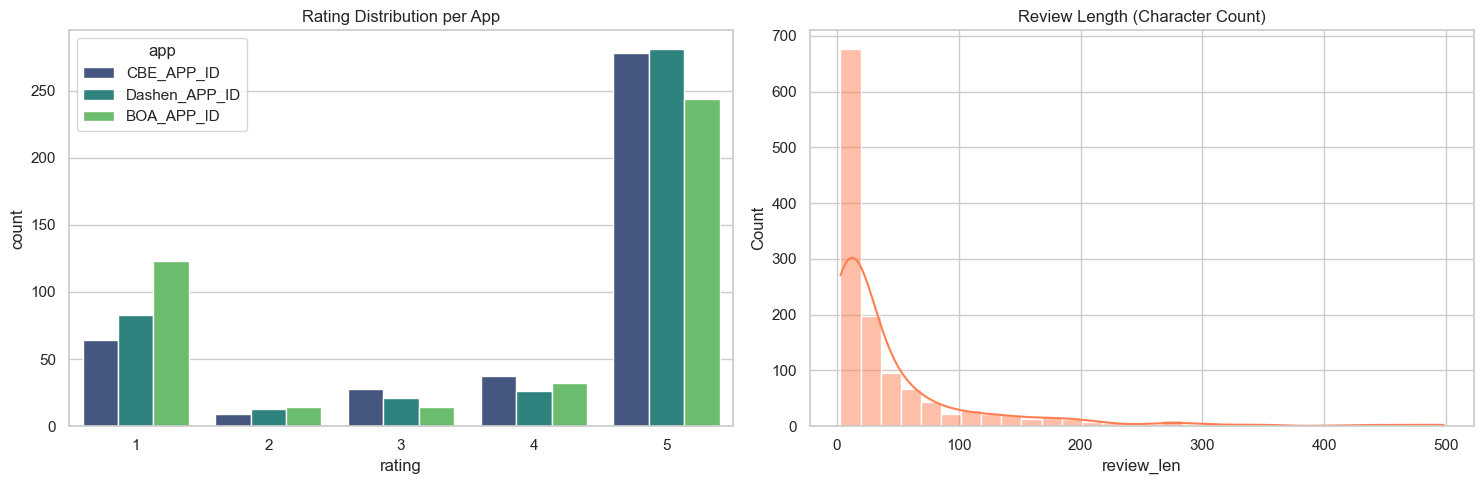

In [6]:
# Visualizing Distributions
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Rating per App
sns.countplot(data=df_clean, x='rating', hue='app', palette='viridis', ax=ax[0])
ax[0].set_title('Rating Distribution per App')

# Review Length
df_clean['review_len'] = df_clean['review'].str.len()
sns.histplot(df_clean['review_len'], bins=30, kde=True, ax=ax[1], color='coral')
ax[1].set_title('Review Length (Character Count)')

plt.tight_layout(); plt.show()

## Section 6 — NLP Pipeline: Keyword Extraction

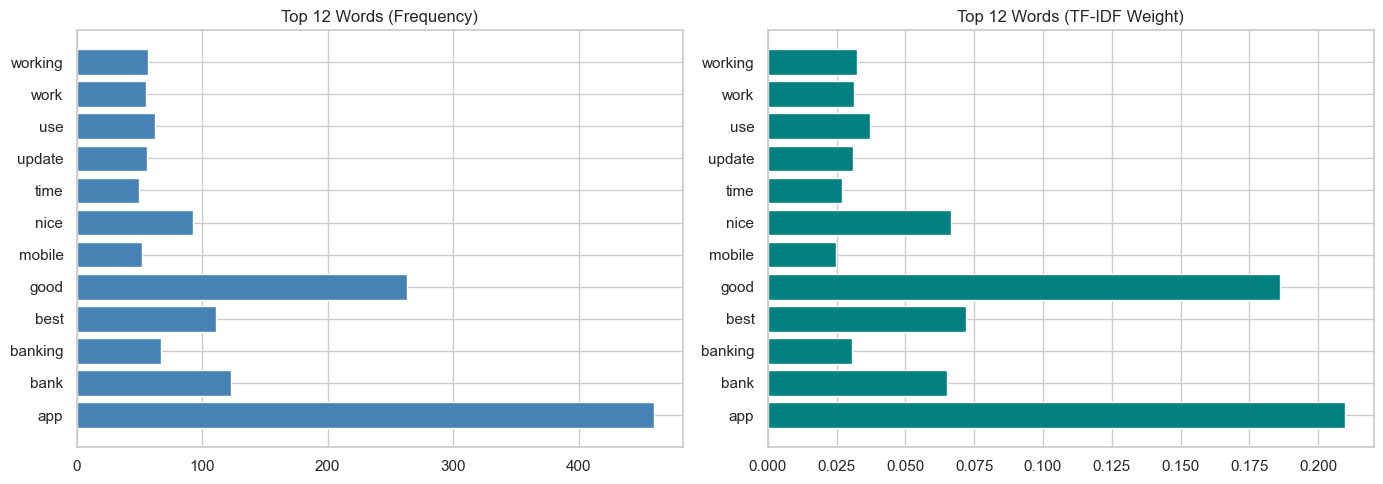

In [8]:

# Frequency (BoW) vs TF-IDF
tfidf_vec = TfidfVectorizer(max_features=12, stop_words='english')
X_tfidf = tfidf_vec.fit_transform(df_clean['clean_text'])

cv_vec = CountVectorizer(max_features=12, stop_words='english')
X_cv = cv_vec.fit_transform(df_clean['clean_text'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(cv_vec.get_feature_names_out(), X_cv.toarray().sum(axis=0), color='steelblue')
axes[0].set_title('Top 12 Words (Frequency)')

axes[1].barh(tfidf_vec.get_feature_names_out(), X_tfidf.toarray().mean(axis=0), color='teal')
axes[1].set_title('Top 12 Words (TF-IDF Weight)')

plt.tight_layout(); plt.show()

## Section 7 — N-gram Analysis (Context Discovery)

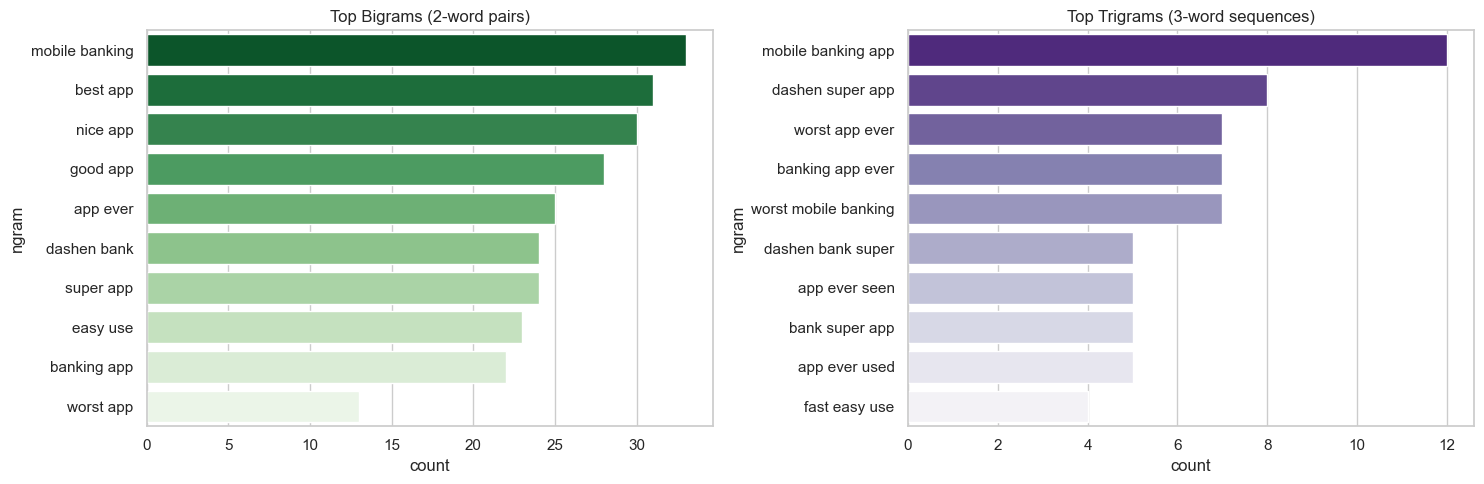

In [9]:

def get_top_ngrams(corpus, n, k=10):
    vec = CountVectorizer(ngram_range=(n,n), max_features=100)
    X = vec.fit_transform(corpus)
    counts = X.sum(axis=0).A1
    return pd.DataFrame({'ngram': vec.get_feature_names_out(), 'count': counts}).sort_values('count', ascending=False).head(k)

bi = get_top_ngrams(df_clean['clean_text'], 2)
tri = get_top_ngrams(df_clean['clean_text'], 3)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(data=bi, x='count', y='ngram', ax=axes[0], palette='Greens_r')
axes[0].set_title('Top Bigrams (2-word pairs)')
sns.barplot(data=tri, x='count', y='ngram', ax=axes[1], palette='Purples_r')
axes[1].set_title('Top Trigrams (3-word sequences)')
plt.tight_layout(); plt.show()

## Section 8 — POS Tagging & Noun Extraction

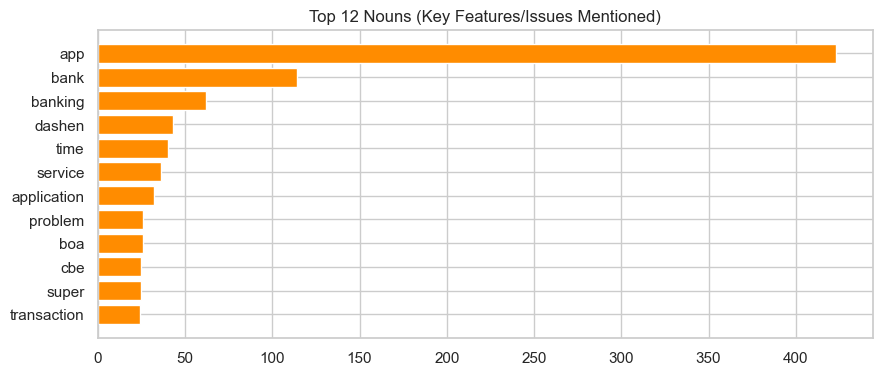

In [10]:
# Identifying Product Features (Nouns)
import nltk
from nltk import word_tokenize, pos_tag
from collections import Counter
import matplotlib.pyplot as plt

try:
    nltk.data.find('taggers/averaged_perceptron_tagger_eng')
except LookupError:
    nltk.download('averaged_perceptron_tagger_eng', quiet=True)

def extract_nouns(text):
    tokens = word_tokenize(text)
    return [w.lower() for w, p in pos_tag(tokens) if p.startswith('NN') and len(w) > 2 and w.lower() not in stop_words]

df_clean['nouns'] = df_clean['review'].apply(extract_nouns)
all_nouns = [n for ns in df_clean['nouns'] for n in ns]
noun_counts = Counter(all_nouns).most_common(12)

plt.figure(figsize=(10, 4))
plt.barh([x[0] for x in noun_counts][::-1], [x[1] for x in noun_counts][::-1], color='darkorange')
plt.title('Top 12 Nouns (Key Features/Issues Mentioned)')
plt.show()

## Section 9 — Word Cloud Visualization

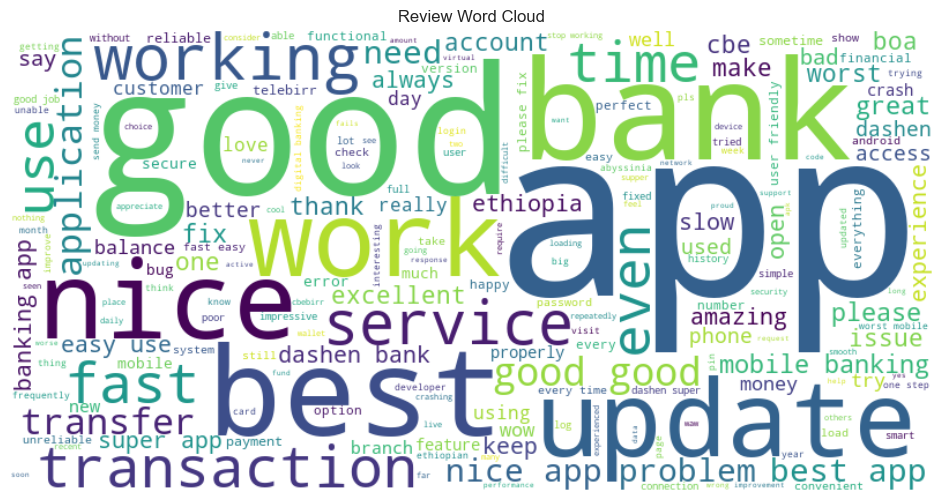

In [11]:
# Word Cloud
text_combined = " ".join(df_clean['clean_text'])
wc = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(text_combined)

plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Review Word Cloud')
plt.show()

## Section 10 — Multi-Model Sentiment Analysis

### Lexicon Comparison
We use **TextBlob** (Polarity & Subjectivity) and **VADER** (Compound Score).
- **Polarity**: [-1, 1] (Negative to Positive)
- **Subjectivity**: [0, 1] (Fact to Opinion)


In [12]:
# Sentiment Application
df_clean['vader_compound'] = df_clean['review'].apply(lambda x: sia.polarity_scores(x)['compound'])
df_clean['tb_polarity'] = df_clean['review'].apply(lambda x: TextBlob(x).sentiment.polarity)
df_clean['tb_subjectivity'] = df_clean['review'].apply(lambda x: TextBlob(x).sentiment.subjectivity)

def get_label(s):
    return 'positive' if s >= 0.05 else ('negative' if s <= -0.05 else 'neutral')

df_clean['sentiment'] = df_clean['vader_compound'].apply(get_label)
print("VADER Distribution:\n", df_clean['sentiment'].value_counts(normalize=True).round(2))

VADER Distribution:
 sentiment
positive    0.62
neutral     0.25
negative    0.13
Name: proportion, dtype: float64


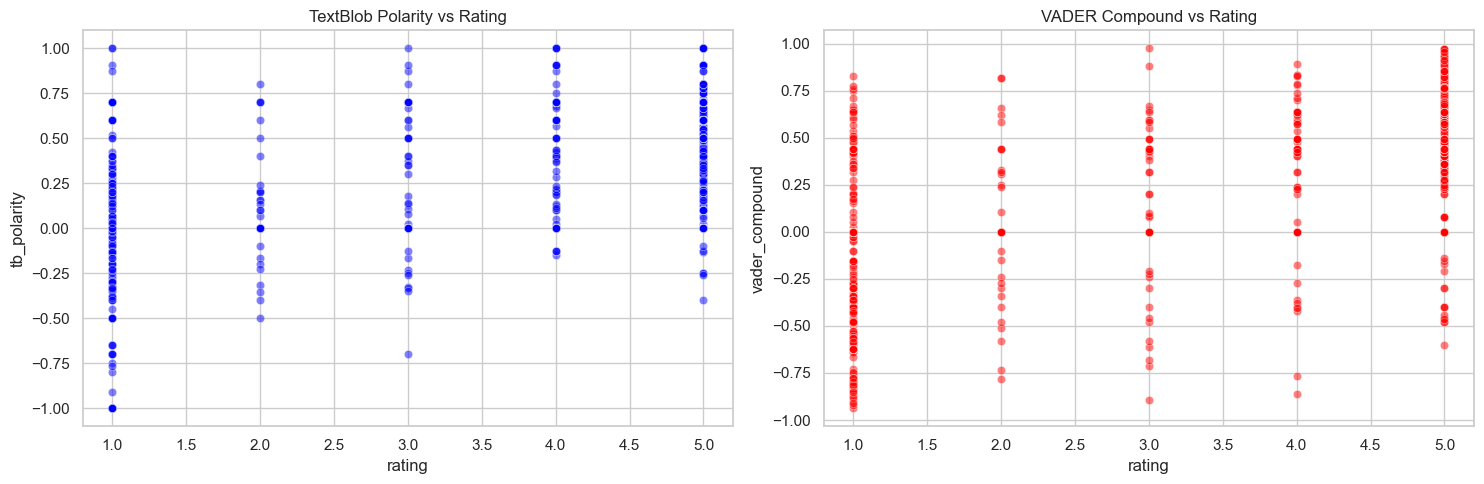

In [13]:
# Sentiment vs. Star Rating
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# TextBlob Scatter
sns.scatterplot(data=df_clean, x='rating', y='tb_polarity', alpha=0.5, ax=axes[0], color='blue')
axes[0].set_title('TextBlob Polarity vs Rating')

# VADER Scatter
sns.scatterplot(data=df_clean, x='rating', y='vader_compound', alpha=0.5, ax=axes[1], color='red')
axes[1].set_title('VADER Compound vs Rating')

plt.tight_layout(); plt.show()

### Transformer-based Sentiment (Template)
Transformers are the gold standard for accuracy.


In [ ]:
# Change this import
from tqdm import tqdm 

try:
    from transformers import pipeline
    
    # Load the model
    sent_model = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english")

    # Apply transformer to all reviews
    transformer_results =[]
    batch_size = 16 
    
    # Using standard tqdm here
    for i in tqdm(range(0, len(df_clean), batch_size), desc="Running Transformer Sentiment"):
        batch = df_clean['review'].iloc[i:i + batch_size].tolist()
        preds = sent_model(batch)
        transformer_results.extend(preds)

    df_clean['transformer_sentiment_label'] = [p['label'] for p in transformer_results]
    
    # Calculate score: positive stays positive, negative becomes negative
    df_clean['transformer_sentiment_score'] = [p['score'] if p['label'] == 'POSITIVE' else -p['score'] for p in transformer_results]

    print("\nTransformer Sentiment Distribution:")
    print(df_clean['transformer_sentiment_label'].value_counts(normalize=True).round(2))

except Exception as e:
    print(f"Transformer process failed: {e}")

Running Transformer Sentiment: 100%|██████████| 80/80 [00:33<00:00,  2.36it/s]


Transformer Sentiment Distribution:
transformer_sentiment_label
POSITIVE    0.63
NEGATIVE    0.37
Name: proportion, dtype: float64


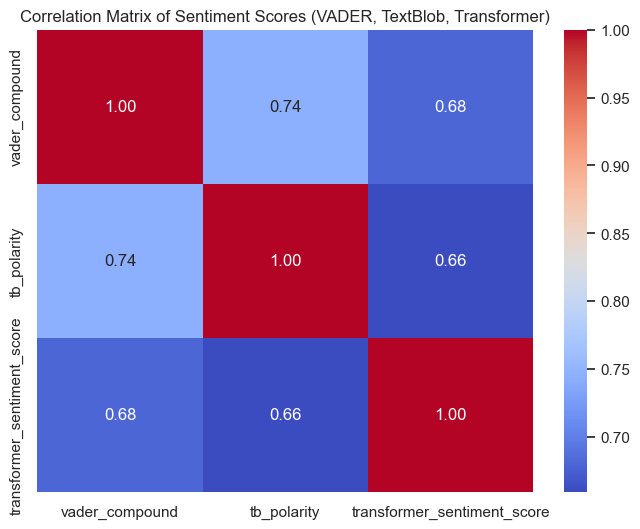

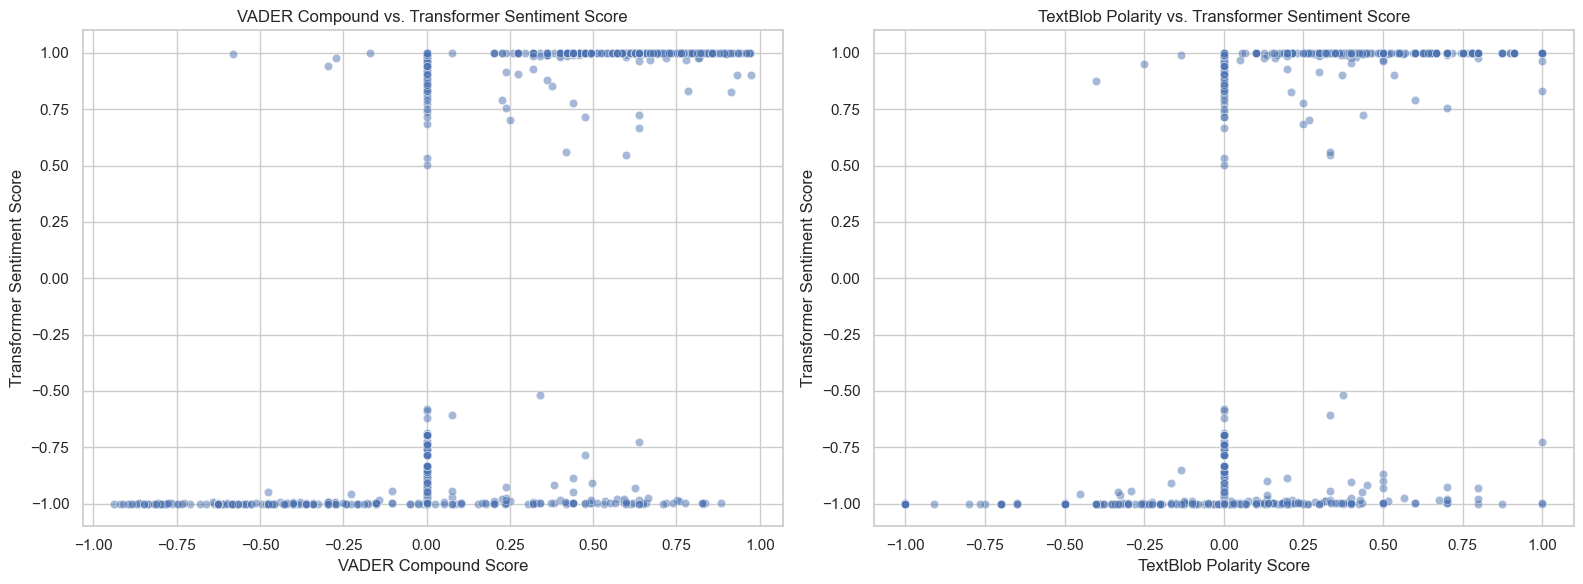

In [24]:
# Visualizing Sentiment Score Correlation

# Ensure transformer_sentiment_score is available
if 'transformer_sentiment_score' not in df_clean.columns:
    print("Transformer sentiment scores not available for comparison.")
else:
    # Create a DataFrame for correlation
    sentiment_scores = df_clean[['vader_compound', 'tb_polarity', 'transformer_sentiment_score']]

    # Calculate the correlation matrix
    correlation_matrix = sentiment_scores.corr()

    plt.figure(figsize=(8, 6))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title('Correlation Matrix of Sentiment Scores (VADER, TextBlob, Transformer)')
    plt.show()

    # Plotting scatter plots for pairwise comparison
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    sns.scatterplot(data=df_clean, x='vader_compound', y='transformer_sentiment_score', alpha=0.5, ax=axes[0])
    axes[0].set_title('VADER Compound vs. Transformer Sentiment Score')
    axes[0].set_xlabel('VADER Compound Score')
    axes[0].set_ylabel('Transformer Sentiment Score')

    sns.scatterplot(data=df_clean, x='tb_polarity', y='transformer_sentiment_score', alpha=0.5, ax=axes[1])
    axes[1].set_title('TextBlob Polarity vs. Transformer Sentiment Score')
    axes[1].set_xlabel('TextBlob Polarity Score')
    axes[1].set_ylabel('Transformer Sentiment Score')

    plt.tight_layout()
    plt.show()

In [25]:
# Comparing Sentiment Distributions

if 'transformer_sentiment_label' not in df_clean.columns:
    print("Transformer sentiment labels not available for comparison.")
else:
    print("\n--- Sentiment Label Distributions ---")
    print("VADER Distribution:\n", df_clean['sentiment'].value_counts(normalize=True).round(2))
    print("\nTextBlob Polarity Distribution (thresholded at +/-0.05):\n")
    def get_tb_label(s):
        return 'positive' if s >= 0.05 else ('negative' if s <= -0.05 else 'neutral')
    print(df_clean['tb_polarity'].apply(get_tb_label).value_counts(normalize=True).round(2))
    print("\nTransformer Distribution:\n", df_clean['transformer_sentiment_label'].value_counts(normalize=True).round(2))


--- Sentiment Label Distributions ---
VADER Distribution:
 sentiment
positive    0.62
neutral     0.25
negative    0.13
Name: proportion, dtype: float64

TextBlob Polarity Distribution (thresholded at +/-0.05):

tb_polarity
positive    0.62
neutral     0.28
negative    0.10
Name: proportion, dtype: float64

Transformer Distribution:
 transformer_sentiment_label
POSITIVE    0.63
NEGATIVE    0.37
Name: proportion, dtype: float64


## Aggregating Sentiment Scores by App and Star Rating

rating,1,2,3,4,5
app,,,,,
BOA_APP_ID,-0.184189,-0.017671,0.192571,0.290806,0.347458
CBE_APP_ID,-0.006573,0.175733,-0.054775,0.179551,0.403119
Dashen_APP_ID,-0.158135,0.009985,0.297543,0.416723,0.453118


rating,1,2,3,4,5
app,,,,,
BOA_APP_ID,-0.106372,0.033801,0.252768,0.386536,0.474106
CBE_APP_ID,0.019305,0.144613,0.163501,0.252439,0.519423
Dashen_APP_ID,-0.165789,0.147930,0.232860,0.463903,0.473141


rating,1,2,3,4,5
app,,,,,
BOA_APP_ID,-0.810162,-0.673774,-0.024293,0.017675,0.631877
CBE_APP_ID,-0.552786,-0.776618,-0.344583,-0.100737,0.754195
Dashen_APP_ID,-0.778711,-0.681445,-0.510394,0.371457,0.763159


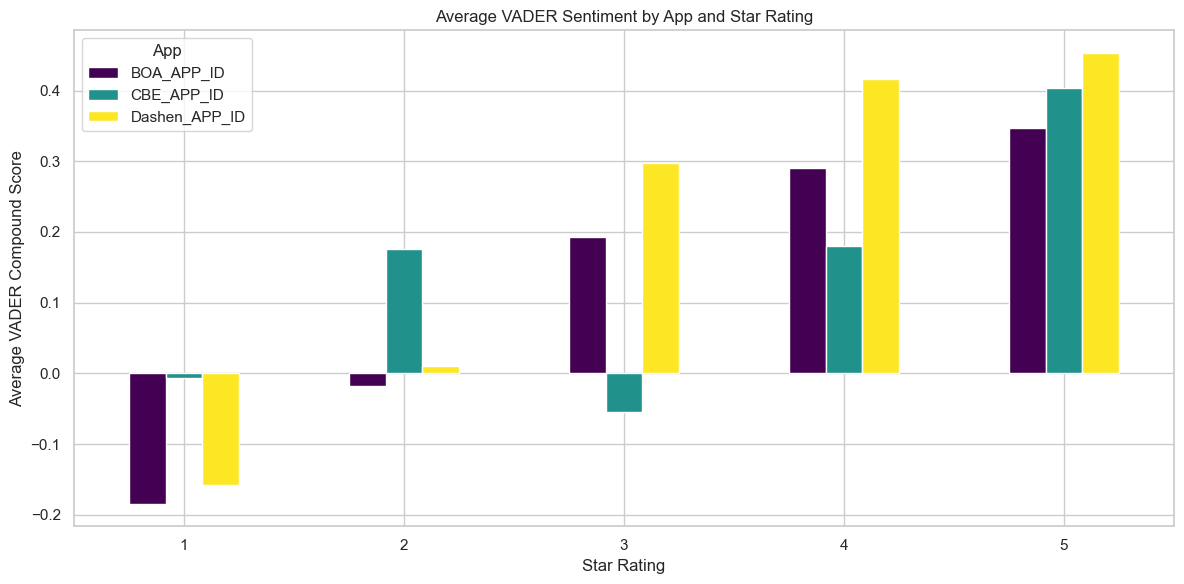

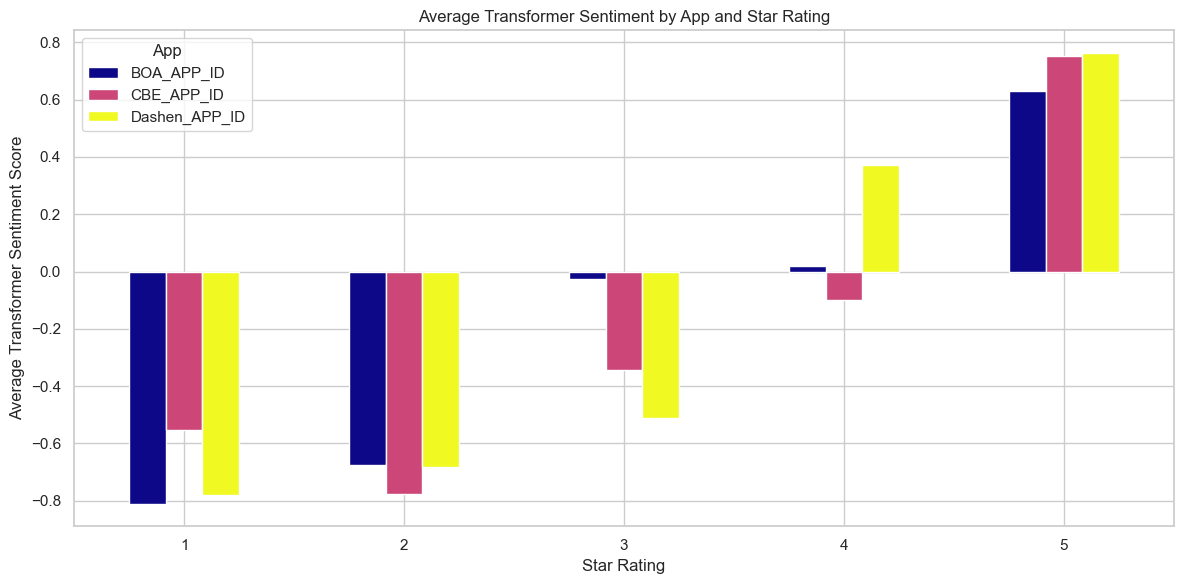

In [26]:
# Aggregate VADER sentiment scores by app and star rating
vader_agg_sentiment = df_clean.groupby(['app', 'rating'])['vader_compound'].mean().unstack()
display(vader_agg_sentiment)

# Aggregate TextBlob polarity scores by app and star rating
tb_agg_sentiment = df_clean.groupby(['app', 'rating'])['tb_polarity'].mean().unstack()
display(tb_agg_sentiment)

# Aggregate Transformer sentiment scores by app and star rating
transformer_agg_sentiment = df_clean.groupby(['app', 'rating'])['transformer_sentiment_score'].mean().unstack()
display(transformer_agg_sentiment)

# Visualize VADER sentiment by app and rating
vader_agg_sentiment.T.plot(kind='bar', figsize=(12, 6), colormap='viridis')
plt.title('Average VADER Sentiment by App and Star Rating')
plt.xlabel('Star Rating')
plt.ylabel('Average VADER Compound Score')
plt.xticks(rotation=0)
plt.legend(title='App')
plt.tight_layout()
plt.show()

# Visualize Transformer sentiment by app and rating
transformer_agg_sentiment.T.plot(kind='bar', figsize=(12, 6), colormap='plasma')
plt.title('Average Transformer Sentiment by App and Star Rating')
plt.xlabel('Star Rating')
plt.ylabel('Average Transformer Sentiment Score')
plt.xticks(rotation=0)
plt.legend(title='App')
plt.tight_layout()
plt.show()

## Section 11 — Thematic Analysis (Actionable Topics)

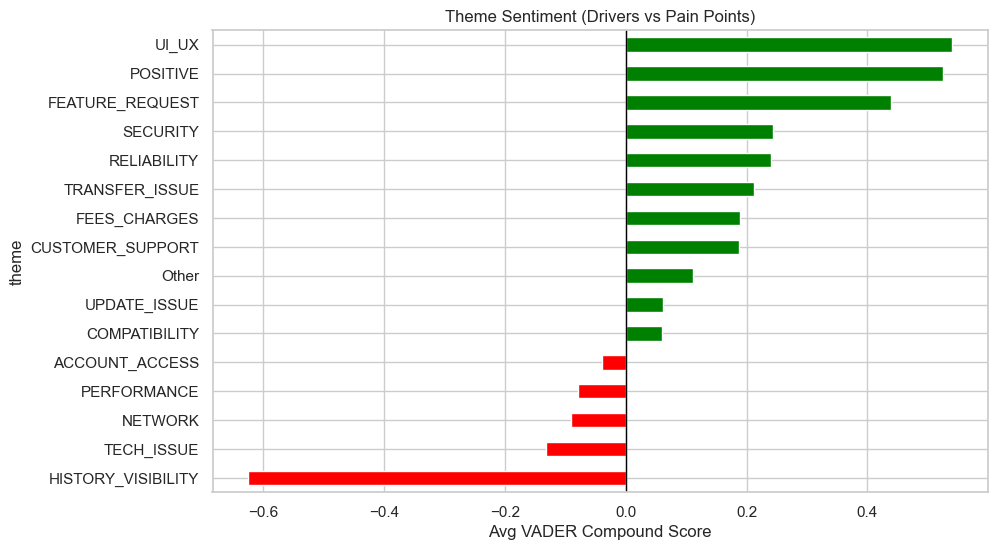

In [27]:
# Cell 12: Business Theme Mapping
THEME_MAP = {

    'TECH_ISSUE': [
        'crash', 'freeze', 'bug',
        'error', 'stuck',
        'failed', 'not working'
    ],

    'TRANSFER_ISSUE': [
        'transfer', 'transaction',
        'payment', 'telebirr',
        'wallet', 'other bank',
        'money'
    ],

    'PERFORMANCE': [
        'slow', 'lag',
        'loading', 'speed',
        'takes forever'
    ],

    'UPDATE_ISSUE': [
        'update', 'updated',
        'force update'
    ],

    'UI_UX': [
        'ui', 'ux',
        'interface', 'design',
        'easy', 'navigation',
        'user friendly'
    ],

    'SECURITY': [
        'secure', 'security',
        'otp', 'password',
        'pin', 'fingerprint',
        'biometric'
    ],

    'COMPATIBILITY': [
        'android', 'huawei',
        'device', 'compatibility'
    ],

    'FEATURE_REQUEST': [
        'please add',
        'should include',
        'allow',
        'consider adding'
    ],

    'CUSTOMER_SUPPORT': [
        'support',
        'customer service',
        'branch',
        'help'
    ],

    'RELIABILITY': [
        'sync',
        'unavailable',
        'unable to connect'
    ],

    'ACCOUNT_ACCESS': [
        'login',
        'sign in',
        'access',
        'session expired',
        'verify'
    ],

    'FEES_CHARGES': [
        'fee',
        'charge',
        'vat'
    ],

    'NETWORK': [
        'network',
        'wifi',
        'internet',
        '4g',
        'safaricom'
    ],

    'HISTORY_VISIBILITY': [
        'history',
        'mini statement',
        'recent transactions'
    ],

    'POSITIVE': [
        'good',
        'best',
        'excellent',
        'amazing',
        'love',
        'great',
        'perfect',
        'wonderful'
    ]
}


def get_theme(txt):
    txt = txt.lower()
    for theme, keywords in THEME_MAP.items():
        if any(w in txt for w in keywords): return theme
    return 'Other'

df_clean['theme'] = df_clean['review'].apply(get_theme)
theme_sent = df_clean.groupby('theme')['vader_compound'].mean().sort_values()

plt.figure(figsize=(10, 6))
colors = ['red' if x < 0 else 'green' for x in theme_sent.values]
theme_sent.plot(kind='barh', color=colors)
plt.title('Theme Sentiment (Drivers vs Pain Points)')
plt.xlabel('Avg VADER Compound Score')
plt.axvline(0, color='black', lw=1)
plt.show()

## Results Export


In [28]:
# Saving Results
output_cols = ['app', 'review', 'rating', 'sentiment', 'vader_compound', 'theme']
df_final = df_clean[output_cols]

# Save to CSV
df_final.to_csv('fintech_sentiment_analysis_results.csv', index=False)
print("✓ Pipeline results saved as 'fintech_sentiment_analysis_results.csv'")
df_final.head()

✓ Pipeline results saved as 'fintech_sentiment_analysis_results.csv'


,app,review,rating,sentiment,vader_compound,theme
0,CBE_APP_ID,worst,1,negative,-0.6249,Other
1,CBE_APP_ID,this app very full,5,neutral,0.0000,Other
2,CBE_APP_ID,good apps,4,positive,0.4404,POSITIVE
3,CBE_APP_ID,this update got crazy i don't know what's goin...,1,positive,0.4767,PERFORMANCE
4,CBE_APP_ID,thanks for you 😘,5,positive,0.4404,Other


In [35]:

df_export_full = df_clean.copy()

# Create review_id from the current index before resetting
df_export_full = df_export_full.reset_index()
df_export_full = df_export_full.rename(columns={'index': 'review_id'})

# Rename columns to match user's request
df_export_full.rename(columns={
    'app': 'bank_id',
    'review': 'review_text',
    'date': 'review_date',
    'transformer_sentiment_label': 'sentiment_label',
    'transformer_sentiment_score': 'sentiment_score',
    'theme': 'identified_theme'
}, inplace=True)
# Add 'source' column
df_export_full['source'] = 'Google Play Store'
df_export_full['bank_name'] = df_export_full['bank_id'].str.replace('_APP_ID', '').str.replace('_', ' ').str.title()
df_export_full['app_name'] = df_export_full['bank_name'] + ' Mobile App'

# Saving Results
output_cols = ["bank_name","app_name","review_id", "bank_id", "review_text", "rating", "review_date",
        "sentiment_label", "sentiment_score", "identified_theme", "source"]
df_final = df_export_full[output_cols]

# Save to CSV
df_final.to_csv('fintech_sentiment_analysis_results_2.csv', index=False)
print("✓ Pipeline results saved as 'fintech_sentiment_analysis_results.csv'")
df_final.head()

✓ Pipeline results saved as 'fintech_sentiment_analysis_results.csv'


,bank_name,app_name,review_id,bank_id,review_text,rating,review_date,sentiment_label,sentiment_score,identified_theme,source
0,Cbe,Cbe Mobile App,0,CBE_APP_ID,worst,1,2026-05-16,NEGATIVE,-0.999802,Other,Google Play Store
1,Cbe,Cbe Mobile App,1,CBE_APP_ID,this app very full,5,2026-05-16,POSITIVE,0.997449,Other,Google Play Store
2,Cbe,Cbe Mobile App,2,CBE_APP_ID,good apps,4,2026-05-16,POSITIVE,0.999861,POSITIVE,Google Play Store
3,Cbe,Cbe Mobile App,3,CBE_APP_ID,this update got crazy i don't know what's goin...,1,2026-05-15,NEGATIVE,-0.999513,PERFORMANCE,Google Play Store
4,Cbe,Cbe Mobile App,4,CBE_APP_ID,thanks for you 😘,5,2026-05-15,POSITIVE,0.999622,Other,Google Play Store


In [ ]:
# READ THE CSV BACK (Method 1: Simple)
df_loaded = pd.read_csv('fintech_sentiment_analysis_results_2.csv')

print(f"✓ Loaded {len(df_loaded)} rows")
print(f"\nColumn names: {list(df_loaded.columns)}")
print(f"\nData types:\n{df_loaded.dtypes}")
print(f"\nFirst 3 rows:")
df_loaded.head(3)

✓ Loaded 1267 rows

Column names: ['bank_name', 'app_name', 'review_id', 'bank_id', 'review_text', 'rating', 'review_date', 'sentiment_label', 'sentiment_score', 'identified_theme', 'source']

Data types:
bank_name               str
app_name                str
review_id             int64
bank_id                 str
review_text             str
rating                int64
review_date             str
sentiment_label         str
sentiment_score     float64
identified_theme        str
source                  str
dtype: object

First 3 rows:


,bank_name,app_name,review_id,bank_id,review_text,rating,review_date,sentiment_label,sentiment_score,identified_theme,source
0,Cbe,Cbe Mobile App,0,CBE_APP_ID,worst,1,2026-05-16,NEGATIVE,-0.999802,Other,Google Play Store
1,Cbe,Cbe Mobile App,1,CBE_APP_ID,this app very full,5,2026-05-16,POSITIVE,0.997449,Other,Google Play Store
2,Cbe,Cbe Mobile App,2,CBE_APP_ID,good apps,4,2026-05-16,POSITIVE,0.999861,POSITIVE,Google Play Store


In [34]:
# READ THE CSV BACK (Method 2: Robust with encoding handling)
import os

csv_file = 'fintech_sentiment_analysis_results_2.csv'
encodings = ["utf-8", "latin-1", "cp1252"]

df_loaded = None
for enc in encodings:
    try:
        df_loaded = pd.read_csv(csv_file, encoding=enc)
        print(f"✓ Successfully read with encoding: {enc}")
        break
    except Exception as e:
        print(f"✗ Failed with {enc}")

if df_loaded is not None:
    # Fix column types
    df_loaded['rating'] = pd.to_numeric(df_loaded['rating'], errors='coerce')
    df_loaded['sentiment_score'] = pd.to_numeric(df_loaded['sentiment_score'], errors='coerce')
    df_loaded['review_date'] = pd.to_datetime(df_loaded['review_date'], errors='coerce')
    
    print(f"\n✓ Loaded successfully: {len(df_loaded)} reviews with {len(df_loaded.columns)} columns")
    print(f"\nColumns: {list(df_loaded.columns)}")
    df_loaded.head()

✓ Successfully read with encoding: utf-8

✓ Loaded successfully: 1267 reviews with 9 columns

Columns: ['review_id', 'bank_id', 'review_text', 'rating', 'review_date', 'sentiment_label', 'sentiment_score', 'identified_theme', 'source']
